## Physics-informed neural network (PINN)

### Train PINN

#### Check GPU settings for NN training

In [5]:
import tensorflow as tf
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
print("GPU Devices:", tf.config.list_physical_devices('GPU'))

Num GPUs Available:  0
GPU Devices: []


In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import shap
import random
import os

# Reproducibility setup
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)
os.environ['TF_DETERMINISTIC_OPS'] = '1'

# === Load and preprocess data ===
data = pd.read_csv('prepared_data_1hr.csv', index_col=0)
timestep = 3600

data['time'] = (data['time'] // timestep) * timestep
data = data.groupby('time').last()

features = ['tesBed.uModActual.y', 
            'tesBed.TOut.y', 
            #'tesBed.weaBus.TWetBul', # Toa wet bulb
            #'tesBed.ave.y', # Average Zonal temperature  
            'tesBed.ave.y_his1', 
            'tesBed.weaBus.HGloHor'# solar irradiation features
            ]
target = ['Ptot']

X = data[features].values
Y = data[target].values

# # Split dataset chronologically (not randomly)
# split_point = int(0.8 * len(X))
# x_train, x_test = X[:split_point], X[split_point:]
# y_train, y_test = Y[:split_point], Y[split_point:]
# === Randomly split dataset ===
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# Enforce a hard constraint such that predicted power is exactly zero when tesBed.uModActual.y = 0
# by defining a custom output masking layer
class PowerOutputMasked(tf.keras.layers.Layer):
    def call(self, inputs, power_pred):
        uMod = inputs[:, 0:1]  # assumes uMod is the first input feature
        mask = tf.cast(tf.not_equal(uMod, 0), tf.float32)
        return power_pred * mask


# === Build Neural Network Model ===
# def build_model(input_shape):
#     normalizer = tf.keras.layers.Normalization(axis=-1)
#     model = tf.keras.Sequential([
#         normalizer,
#         tf.keras.layers.Dense(32, activation='relu', kernel_regularizer=tf.keras.regularizers.L2(0.01)), # activation='softplus', 'relu', 'sigmoid'
#         tf.keras.layers.Dense(32, activation='relu', kernel_regularizer=tf.keras.regularizers.L2(0.01)),
#         #tf.keras.layers.Dense(128, activation='relu', kernel_regularizer=tf.keras.regularizers.L2(0.01)),
#         tf.keras.layers.Dense(1)
#     ])
#     normalizer.adapt(x_train)
#     return model

def build_model(input_shape):
    inputs = tf.keras.Input(shape=input_shape)
    x = tf.keras.layers.Normalization(axis=-1)(inputs)
    x = tf.keras.layers.Dense(32, activation='relu', kernel_regularizer=tf.keras.regularizers.L2(0.01))(x)
    x = tf.keras.layers.Dense(32, activation='relu', kernel_regularizer=tf.keras.regularizers.L2(0.01))(x)
    raw_output = tf.keras.layers.Dense(1)(x)

    masked_output = PowerOutputMasked()(inputs, raw_output)
    model = tf.keras.Model(inputs=inputs, outputs=masked_output)

    return model


# === Define Physics-Informed Custom Loss Function ===
def custom_pinn_loss_factory(x_input, model):
    def custom_pinn_loss(y_true, y_pred):
        # 1. Standard MSE
        mse = tf.reduce_mean(tf.square(y_true - y_pred))

        tes_mode = x_input[:, 0]  # Assuming tesBed.uModActual.y is the first feature in x_input
        # # 2. Penalty when mode = 0 (TES off) but power ≠ 0
        # penalty_mode_0 = tf.reduce_mean(
        #     tf.where(tf.equal(tes_mode, 0), tf.square(y_pred), tf.zeros_like(y_pred))
        # )

        # 3. Mode-specific acceptable power bounds
        penalty_ranges = {
            -1: (8000, 9000),
             1: (2000, 14000),
             2: (8000, 33000),
        }
        penalties = []
        for mode_val, (lower, upper) in penalty_ranges.items():
            mask = tf.equal(tes_mode, mode_val)
            out_of_bounds = tf.logical_or(y_pred < lower, y_pred > upper)
            penalty = tf.where(
                tf.logical_and(mask, out_of_bounds),
                tf.square(tf.maximum(lower - y_pred, 0)) + tf.square(tf.maximum(y_pred - upper, 0)),
                tf.zeros_like(y_pred)
            )
            penalties.append(tf.reduce_mean(penalty))
        mode_bound_penalty = tf.add_n(penalties)

        # 4. Monotonicity constraint: ∂P/∂T_out ≥ 0 only when mode = 1 or 2
        with tf.GradientTape() as tape:
            tape.watch(x_input)
            y_pred_ = model(x_input)
        grads = tape.gradient(y_pred_, x_input)
        dP_dTout = grads[:, 1]  # Partial derivative with respect to T_out
        #mono_mask = tf.logical_or(tf.equal(tes_mode, 1), tf.equal(tes_mode, 2))
        mono_mask = tf.equal(tes_mode, 2)
        mono_penalty = tf.reduce_mean(
            tf.where(mono_mask, tf.maximum(0.0, -dP_dTout), tf.zeros_like(dP_dTout))
        )

        # Composite Loss
        total_loss = (
            mse +  0.1 * mode_bound_penalty + 0.05 * mono_penalty # 0.05 * penalty_mode_0 +
        )
        return total_loss
    return custom_pinn_loss

# === Train Model ===
nn_model = build_model((x_train.shape[1],))
loss_fn = custom_pinn_loss_factory(tf.convert_to_tensor(x_train, dtype=tf.float32), nn_model)
nn_model.compile(optimizer='adam', loss=loss_fn)

# Early stopping and LR scheduler
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=10)

# Train the model
history = nn_model.fit(
    x_train, y_train,
    epochs=2000,
    batch_size=64, # 32
    validation_split=0.2,
    #callbacks=[early_stopping, lr_scheduler],
    verbose=1,
)

nn_model.summary()

# Save the model
nn_model.save('./results_pinn/pinn_power_model.h5')

# === Dynamic Retraining with New Data ===
# Assume new_data is provided as a DataFrame with same structure
# new_data = pd.read_csv("new_data.csv")
# new_X = new_data[features].values
# new_Y = new_data[target].values
# X = np.vstack((X, new_X))
# Y = np.vstack((Y, new_Y))
# retrain_model.fit(X, Y, epochs=100, ...)

# === Evaluation and Visualization ===
y_pred_train = nn_model.predict(x_train).flatten()
y_pred_test = nn_model.predict(x_test).flatten()

r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)
mse_train = mean_squared_error(y_train, y_pred_train)
mse_test = mean_squared_error(y_test, y_pred_test)

plt.figure(figsize=(14, 6))
min_val = min(y_train.min(), y_test.min())
max_val = max(y_train.max(), y_test.max())
diagonal = np.linspace(min_val, max_val, 100)

plt.subplot(1, 2, 1)
plt.scatter(y_train, y_pred_train, label='Train', alpha=0.6)
plt.plot(diagonal, diagonal, 'k--')
plt.fill_between(diagonal, 0.85 * diagonal, 1.15 * diagonal, alpha=0.2, color='gray')
plt.title(f'Train R2 = {r2_train:.3f}')
plt.xlabel('True'); plt.ylabel('Predicted'); plt.legend()

plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred_test, label='Test', alpha=0.6)
plt.plot(diagonal, diagonal, 'k--')
plt.fill_between(diagonal, 0.85 * diagonal, 1.15 * diagonal, alpha=0.2, color='gray')
plt.title(f'Test R2 = {r2_test:.3f}')
plt.xlabel('True'); plt.ylabel('Predicted'); plt.legend()

plt.tight_layout()
plt.savefig('./results_pinn/power_scatter.png')
plt.show()

print("Training R2:", r2_train, "Testing R2:", r2_test)
print("Training MSE:", mse_train, "Testing MSE:", mse_test)
print("Training CV(RMSE):", mse_train**0.5/np.mean(y_train), "Testing CV(RMSE):", mse_test**0.5/np.mean(y_test))

Training config: neurons=64, batch_size=32, lr=0.0001, activation=relu
5/5 [==============================] - 0s 2ms/step
--> R2 Score: 0.4847

New best model recorded.

Training config: neurons=64, batch_size=32, lr=0.0001, activation=softplus
5/5 [==============================] - 0s 1ms/step
--> R2 Score: 0.5136

New best model recorded.

Training config: neurons=64, batch_size=32, lr=0.0001, activation=tanh
5/5 [==============================] - 0s 2ms/step
--> R2 Score: -1.0883

Training config: neurons=64, batch_size=32, lr=0.001, activation=relu
5/5 [==============================] - 0s 1ms/step
--> R2 Score: 0.7270

New best model recorded.

Training config: neurons=64, batch_size=32, lr=0.001, activation=softplus
5/5 [==============================] - 0s 1ms/step
--> R2 Score: 0.8209

New best model recorded.

Training config: neurons=64, batch_size=32, lr=0.001, activation=tanh
5/5 [==============================] - 0s 1ms/step
--> R2 Score: -0.8435

Training config: neurons=

You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.


5/5 [==============================] - 0s 1ms/step


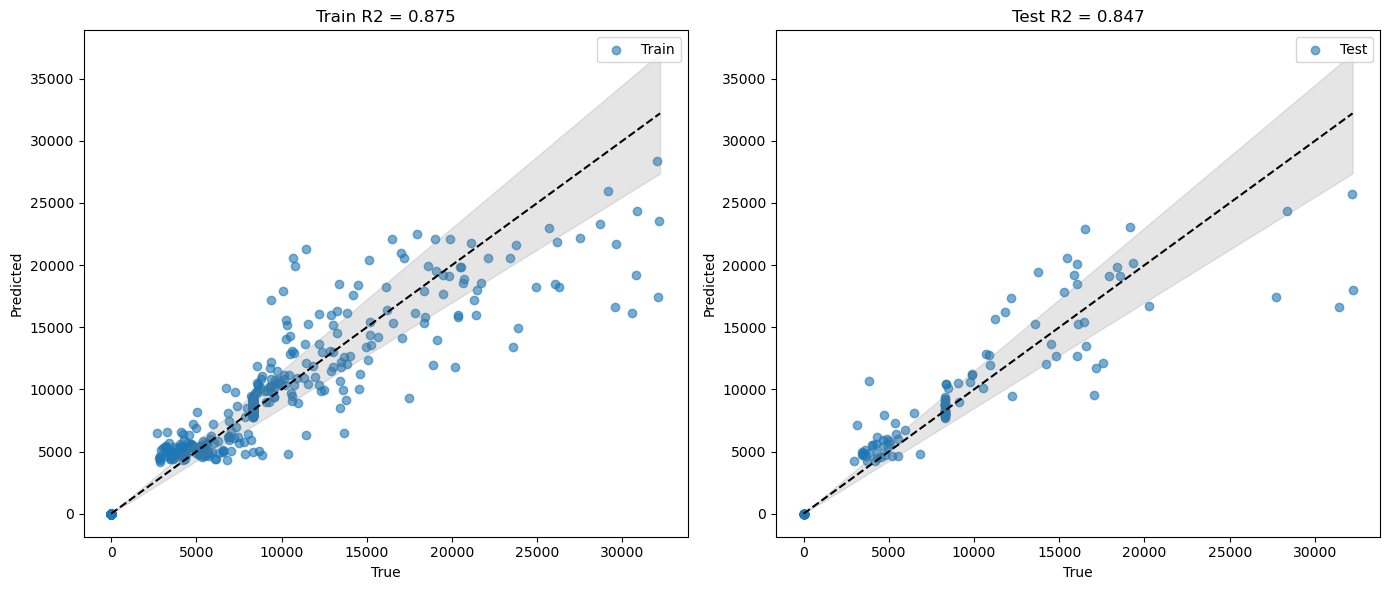

Training R2: 0.8750157277842564 Testing R2: 0.846813731239636
Training MSE: 5295160.952132824 Testing MSE: 7634993.861131665
Training CV(RMSE): 0.31878906058779893 Testing CV(RMSE): 0.36979254863140665


In [14]:
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import shap
import random
import os
from itertools import product

# === Reproducibility setup ===
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)
os.environ['TF_DETERMINISTIC_OPS'] = '1'

# === Load and preprocess data ===
data = pd.read_csv('prepared_data_1hr.csv', index_col=0)
timestep = 3600

# Convert time into hourly intervals and group by last record within each hour
data['time'] = (data['time'] // timestep) * timestep
data = data.groupby('time').last()

# === Feature and target selection ===
features = ['tesBed.uModActual.y', 
            'tesBed.TOut.y', 
            #'tesBed.weaBus.TWetBul',
            #'tesBed.ave.y',
            'tesBed.ave.y_his1',
            #'tesBed.weaBus.HGloHor',
            ]
target = ['Ptot']

# === Prepare data arrays ===
X = data[features].values
Y = data[target].values
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# === Custom masking layer to enforce P=0 when uMod==0 ===
class PowerOutputMasked(tf.keras.layers.Layer):
    def call(self, inputs, power_pred):
        uMod = inputs[:, 0:1]  # Extract control mode from inputs
        mask = tf.cast(tf.not_equal(uMod, 0), tf.float32)  # Mask = 0 if uMod == 0
        return power_pred * mask  # Enforce zero output for mode 0

# === Dynamic model builder with customizable neurons and activation ===
def build_model(input_shape, n_units, activation):
    inputs = tf.keras.Input(shape=input_shape)
    x = tf.keras.layers.Normalization(axis=-1)(inputs)
    x = tf.keras.layers.Dense(n_units, activation=activation, kernel_regularizer=tf.keras.regularizers.L2(0.01))(x)
    x = tf.keras.layers.Dense(n_units, activation=activation, kernel_regularizer=tf.keras.regularizers.L2(0.01))(x)
    raw_output = tf.keras.layers.Dense(1)(x)
    masked_output = PowerOutputMasked()(inputs, raw_output)
    return tf.keras.Model(inputs=inputs, outputs=masked_output)

# === Physics-informed custom loss factory ===
def custom_pinn_loss_factory(x_input, model):
    def custom_pinn_loss(y_true, y_pred):
        mse = tf.reduce_mean(tf.square(y_true - y_pred))
        tes_mode = x_input[:, 0]

        # Constraint: output must fall within acceptable power bounds for each mode
        penalty_ranges = {
            -1: (8000, 9000),
             1: (2000, 14000),
             2: (8000, 33000),
        }
        penalties = []
        for mode_val, (lower, upper) in penalty_ranges.items():
            mask = tf.equal(tes_mode, mode_val)
            out_of_bounds = tf.logical_or(y_pred < lower, y_pred > upper)
            penalty = tf.where(tf.logical_and(mask, out_of_bounds),
                               tf.square(tf.maximum(lower - y_pred, 0)) + tf.square(tf.maximum(y_pred - upper, 0)),
                               tf.zeros_like(y_pred))
            penalties.append(tf.reduce_mean(penalty))
        mode_bound_penalty = tf.add_n(penalties)

        # Constraint: ∂P/∂T_out ≥ 0 for mode 2 (monotonicity)
        with tf.GradientTape() as tape:
            tape.watch(x_input)
            y_pred_ = model(x_input)
        grads = tape.gradient(y_pred_, x_input)
        dP_dTout = grads[:, 1]  # Partial derivative w.r.t. outdoor temperature
        mono_mask = tf.equal(tes_mode, 2)
        mono_penalty = tf.reduce_mean(tf.where(mono_mask, tf.maximum(0.0, -dP_dTout), tf.zeros_like(dP_dTout)))

        total_loss = mse + 0.1 * mode_bound_penalty + 0.05 * mono_penalty
        return total_loss
    return custom_pinn_loss

# === Grid search hyperparameters ===
neurons_list = [32, 64]  # Number of units in hidden layers
batch_sizes = [32, 64]   # Training batch sizes
learning_rates = [0.0001, 0.001, 0.01]  # Optimizer learning rates
activations = ['relu', 'softplus', 'tanh']  # Activation functions to try

# Track best performance
best_r2 = -np.inf
best_model = None

# Grid search loop
for n in neurons_list:
    for bs in batch_sizes:
        for lr in learning_rates:
            for act in activations:
                print(f"Training config: neurons={n}, batch_size={bs}, lr={lr}, activation={act}")

                model = build_model((x_train.shape[1],), n, act)
                loss_fn = custom_pinn_loss_factory(tf.convert_to_tensor(x_train, dtype=tf.float32), model)
                model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=lr), loss=loss_fn)

                history = model.fit(
                    x_train, y_train,
                    epochs=1000,
                    batch_size=bs,
                    validation_split=0.2,
                    verbose=0
                )

                y_pred = model.predict(x_test).flatten()
                r2 = r2_score(y_test, y_pred)
                print(f"--> R2 Score: {r2:.4f}\n")

                if r2 > best_r2:
                    best_r2 = r2
                    best_model = model
                    print("New best model recorded.\n")

# === Save the best model ===
best_model.save('./results_pinn/pinn_power_model.h5')

# === Evaluation of best model from grid search ===
y_pred_train = best_model.predict(x_train).flatten()
y_pred_test = best_model.predict(x_test).flatten()

r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)
mse_train = mean_squared_error(y_train, y_pred_train)
mse_test = mean_squared_error(y_test, y_pred_test)

plt.figure(figsize=(14, 6))
min_val = min(y_train.min(), y_test.min())
max_val = max(y_train.max(), y_test.max())
diagonal = np.linspace(min_val, max_val, 100)

plt.subplot(1, 2, 1)
plt.scatter(y_train, y_pred_train, label='Train', alpha=0.6)
plt.plot(diagonal, diagonal, 'k--')
plt.fill_between(diagonal, 0.85 * diagonal, 1.15 * diagonal, alpha=0.2, color='gray')
plt.title(f'Train R2 = {r2_train:.3f}')
plt.xlabel('True'); plt.ylabel('Predicted'); plt.legend()

plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred_test, label='Test', alpha=0.6)
plt.plot(diagonal, diagonal, 'k--')
plt.fill_between(diagonal, 0.85 * diagonal, 1.15 * diagonal, alpha=0.2, color='gray')
plt.title(f'Test R2 = {r2_test:.3f}')
plt.xlabel('True'); plt.ylabel('Predicted'); plt.legend()

plt.tight_layout()
plt.savefig('./results_pinn/power_scatter.png')
plt.show()

print("Training R2:", r2_train, "Testing R2:", r2_test)
print("Training MSE:", mse_train, "Testing MSE:", mse_test)
print("Training CV(RMSE):", mse_train**0.5/np.mean(y_train), "Testing CV(RMSE):", mse_test**0.5/np.mean(y_test))


In [ ]:
# === Explainability with SHAP ===
# Only use a small sample for SHAP (DeepExplainer is memory-intensive)
background = x_train[:100]
test_sample = x_test[:100]

#explainer = shap.DeepExplainer(nn_model, background)
explainer = shap.KernelExplainer(nn_model.predict, background)
shap_values = explainer.shap_values(test_sample)

shap.summary_plot(shap_values[0], features=test_sample, feature_names=features)

#### Hyperparameter tuning using Optuna

[I 2025-06-04 15:37:09,421] A new study created in memory with name: no-name-b1a3b892-f42b-4b8c-85fe-b63b7fe27559
suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float

Epoch 1/300
30/30 [==============================] - 2s 29ms/step - loss: 98003488.0000 - val_loss: 58410180.0000 - lr: 0.0040
Epoch 2/300
30/30 [==============================] - 0s 9ms/step - loss: 40237428.0000 - val_loss: 19289298.0000 - lr: 0.0040
Epoch 3/300
30/30 [==============================] - 0s 9ms/step - loss: 28652210.0000 - val_loss: 19932592.0000 - lr: 0.0040
Epoch 4/300
30/30 [==============================] - 0s 7ms/step - loss: 23573038.0000 - val_loss: 19186620.0000 - lr: 0.0040
Epoch 5/300
30/30 [==============================] - 0s 9ms/step - loss: 24154176.0000 - val_loss: 18203242.0000 - lr: 0.0040
Epoch 6/300
30/30 [==============================] - 0s 8ms/step - loss: 24707510.0000 - val_loss: 18959136.0000 - lr: 0.0040
Epoch 7/300
30/30 [==============================] - 0s 9ms/step - loss: 25291224.0000 - val_loss: 18158238.0000 - lr: 0.0040
Epoch 8/300
30/30 [==============================] - 0s 8ms/step - loss: 22494208.0000 - val_loss: 17602724.0000 - lr

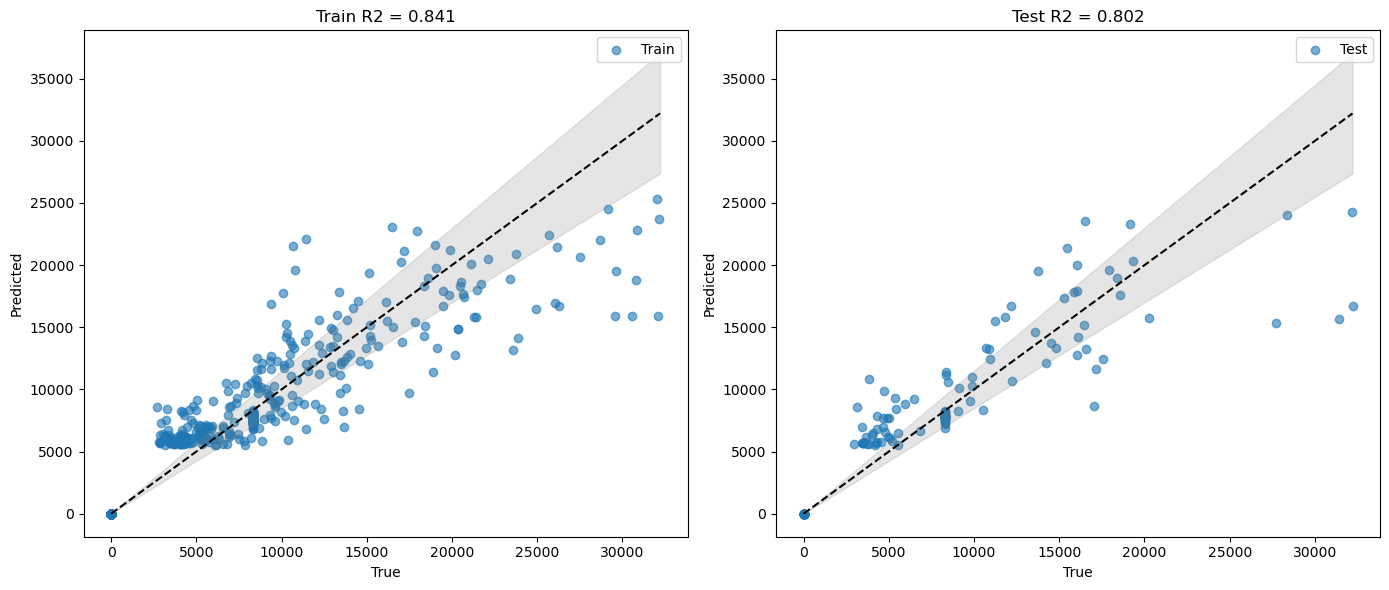

Training R2: 0.8406563883910854 Testing R2: 0.801551427911191
Training MSE: 6750849.968601577 Testing MSE: 9890923.265574295
Training CV(RMSE): 0.35995072723952953
Testing CV(RMSE): 0.4208935069501468


Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.
`tf.keras.backend.set_learning_phase` is deprecated and will be removed after 2020-10-11. To update it, simply pass a True/False value to the `training` argument of the `__call__` method of your layer or model.


AssertionError: The SHAP explanations do not sum up to the model's output! This is either because of a rounding error or because an operator in your computation graph was not fully supported. If the sum difference of 6356.958984 is significant compared the scale of your model outputs please post as a github issue, with a reproducable example if possible so we can debug it.

In [53]:
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import optuna
import random
import os

# Reproducibility
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)
os.environ['TF_DETERMINISTIC_OPS'] = '1'

# === Load and preprocess data ===
data = pd.read_csv('prepared_data_1hr.csv', index_col=0)
timestep = 3600
data['time'] = (data['time'] // timestep) * timestep
data = data.groupby('time').last()

features = ['tesBed.uModActual.y', 'tesBed.TOut.y', 'tesBed.ave.y']
target = ['Ptot']

X = data[features].values
Y = data[target].values

x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# === Custom layer for hard constraint enforcement ===
class PowerOutputMasked(tf.keras.layers.Layer):
    def call(self, inputs, power_pred):
        uMod = inputs[:, 0:1]  # extract uMod from input
        mask = tf.cast(tf.not_equal(uMod, 0), tf.float32)  # 1 if uMod ≠ 0
        return power_pred * mask  # zero out if uMod == 0

# === Build flexible model with hard constraint ===
def build_model_custom(input_dim, n_layers, n_units, activation, l2_lambda, dropout_rate):
    inputs = tf.keras.layers.Input(shape=(input_dim,))
    x = tf.keras.layers.Normalization(axis=-1)(inputs)
    for _ in range(n_layers):
        x = tf.keras.layers.Dense(n_units, activation=activation,
                    kernel_regularizer=tf.keras.regularizers.L2(l2_lambda))(x)
        if dropout_rate > 0:
            x = tf.keras.layers.Dropout(dropout_rate)(x)
    raw_output = tf.keras.layers.Dense(1)(x)
    masked_output = PowerOutputMasked()(inputs, raw_output)
    model = tf.keras.Model(inputs=inputs, outputs=masked_output)
    return model

# === Custom loss with tunable lambda weights ===
def custom_pinn_loss_factory(x_input, model, lambda_mode_0, lambda_bound, lambda_mono):
    def custom_pinn_loss(y_true, y_pred):
        mse = tf.reduce_mean(tf.square(y_true - y_pred))
        tes_mode = x_input[:, 0]
        penalty_mode_0 = tf.reduce_mean(tf.where(tf.equal(tes_mode, 0), tf.square(y_pred), tf.zeros_like(y_pred)))

        penalty_ranges = {
            -1: (8000, 9000),
             1: (2000, 14000),
             2: (8000, 33000),
        }
        penalties = []
        for mode_val, (lower, upper) in penalty_ranges.items():
            mask = tf.equal(tes_mode, mode_val)
            out_of_bounds = tf.logical_or(y_pred < lower, y_pred > upper)
            penalty = tf.where(
                tf.logical_and(mask, out_of_bounds),
                tf.square(tf.maximum(lower - y_pred, 0)) + tf.square(tf.maximum(y_pred - upper, 0)),
                tf.zeros_like(y_pred))
            penalties.append(tf.reduce_mean(penalty))
        mode_bound_penalty = tf.add_n(penalties)

        with tf.GradientTape() as tape:
            tape.watch(x_input)
            y_pred_ = model(x_input)
        grads = tape.gradient(y_pred_, x_input)
        dP_dTout = grads[:, 1]
        mono_mask = tf.equal(tes_mode, 2)
        mono_penalty = tf.reduce_mean(tf.where(mono_mask, tf.maximum(0.0, -dP_dTout), tf.zeros_like(dP_dTout)))

        return mse + lambda_mode_0 * penalty_mode_0 + lambda_bound * mode_bound_penalty + lambda_mono * mono_penalty
    return custom_pinn_loss

# === Optuna tuning objective ===
def objective(trial):
    n_layers = trial.suggest_int('n_hidden_layers', 2, 3)
    n_units = trial.suggest_categorical('n_units', [32, 64, 128])
    activation = trial.suggest_categorical('activation', ['relu', 'softplus', 'tanh'])
    learning_rate = trial.suggest_loguniform('learning_rate', 1e-5, 1e-2)
    l2_lambda = trial.suggest_loguniform('l2_lambda', 1e-6, 1e-2)
    batch_size = trial.suggest_categorical('batch_size', [16, 32, 64])
    dropout_rate = trial.suggest_uniform('dropout_rate', 0.0, 0.5)
    lambda_mode_0 = trial.suggest_uniform('lambda_mode_0', 0.01, 0.2)
    lambda_bound = trial.suggest_uniform('lambda_bound', 0.05, 0.3)
    lambda_mono = trial.suggest_uniform('lambda_mono', 0.01, 0.2)

    model = build_model_custom(x_train.shape[1], n_layers, n_units, activation, l2_lambda, dropout_rate)
    loss_fn = custom_pinn_loss_factory(tf.convert_to_tensor(x_train, dtype=tf.float32), model,
                                       lambda_mode_0, lambda_bound, lambda_mono)
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate), loss=loss_fn)

    early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    history = model.fit(x_train, y_train, epochs=100, batch_size=batch_size,
                        validation_split=0.2, verbose=0, callbacks=[early_stopping])
    return min(history.history['val_loss'])

# === Run Optuna Study ===
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)

# === Final retraining using best trial ===
params = study.best_trial.params
final_model = build_model_custom(x_train.shape[1], params['n_hidden_layers'], params['n_units'],
                                 params['activation'], params['l2_lambda'], params['dropout_rate'])

final_loss_fn = custom_pinn_loss_factory(tf.convert_to_tensor(x_train, dtype=tf.float32), final_model,
                                         params['lambda_mode_0'], params['lambda_bound'], params['lambda_mono'])

final_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=params['learning_rate']),
                    loss=final_loss_fn)

final_callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=7)
]

final_model.fit(x_train, y_train, epochs=300, batch_size=params['batch_size'],
                validation_split=0.2, callbacks=final_callbacks, verbose=1)

final_model.save('./results_pinn/pinn_power_model_best.h5')

# === Evaluation and Visualization of Best Model ===
y_pred_train = final_model.predict(x_train).flatten()
y_pred_test = final_model.predict(x_test).flatten()

r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)
mse_train = mean_squared_error(y_train, y_pred_train)
mse_test = mean_squared_error(y_test, y_pred_test)

plt.figure(figsize=(14, 6))
min_val = min(y_train.min(), y_test.min())
max_val = max(y_train.max(), y_test.max())
diagonal = np.linspace(min_val, max_val, 100)

plt.subplot(1, 2, 1)
plt.scatter(y_train, y_pred_train, label='Train', alpha=0.6)
plt.plot(diagonal, diagonal, 'k--')
plt.fill_between(diagonal, 0.85 * diagonal, 1.15 * diagonal, alpha=0.2, color='gray')
plt.title(f'Train R2 = {r2_train:.3f}')
plt.xlabel('True'); plt.ylabel('Predicted'); plt.legend()

plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred_test, label='Test', alpha=0.6)
plt.plot(diagonal, diagonal, 'k--')
plt.fill_between(diagonal, 0.85 * diagonal, 1.15 * diagonal, alpha=0.2, color='gray')
plt.title(f'Test R2 = {r2_test:.3f}')
plt.xlabel('True'); plt.ylabel('Predicted'); plt.legend()

plt.tight_layout()
plt.savefig('./results_pinn/power_scatter_best.png')
plt.show()

print("Training R2:", r2_train, "Testing R2:", r2_test)
print("Training MSE:", mse_train, "Testing MSE:", mse_test)
print("Training CV(RMSE):", mse_train**0.5 / np.mean(y_train))
print("Testing CV(RMSE):", mse_test**0.5 / np.mean(y_test))


[I 2025-06-13 18:17:35,581] A new study created in memory with name: no-name-afbb7055-c80f-49ee-946d-0eefe39fc4a0
suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.


5/5 [==============================] - 0s 2ms/step


[I 2025-06-13 18:18:07,126] Trial 0 finished with value: 1.0381783404787273 and parameters: {'n_layers': 2, 'n_units': 128, 'activation': 'tanh', 'batch_size': 64, 'lr': 0.0008599455630988089, 'l2_lambda': 5.560594456905533e-05, 'dropout_rate': 0.45829193519529704}. Best is trial 0 with value: 1.0381783404787273.
suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.


5/5 [==============================] - 0s 3ms/step


[I 2025-06-13 18:18:49,495] Trial 1 finished with value: -0.5803983217761275 and parameters: {'n_layers': 3, 'n_units': 128, 'activation': 'relu', 'batch_size': 64, 'lr': 0.0006755958429740069, 'l2_lambda': 0.006933121959245565, 'dropout_rate': 0.3789444855501044}. Best is trial 1 with value: -0.5803983217761275.
suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.


...

5/5 [==============================] - 0s 1ms/step


[I 2025-06-13 18:31:27,151] Trial 29 finished with value: -0.47567835446417384 and parameters: {'n_layers': 2, 'n_units': 32, 'activation': 'softplus', 'batch_size': 64, 'lr': 0.0005632514255861429, 'l2_lambda': 4.139890952189131e-05, 'dropout_rate': 0.06452877075769704}. Best is trial 17 with value: -0.8101425161843511.


Epoch 1/300
15/15 [==============================] - 1s 25ms/step - loss: 53423468.0000 - val_loss: 23825890.0000
Epoch 2/300
15/15 [==============================] - 0s 7ms/step - loss: 31587518.0000 - val_loss: 20075728.0000
Epoch 3/300
15/15 [==============================] - 0s 7ms/step - loss: 32622540.0000 - val_loss: 35650252.0000
Epoch 4/300
15/15 [==============================] - 0s 8ms/step - loss: 28134618.0000 - val_loss: 17783974.0000
Epoch 5/300
15/15 [==============================] - 0s 7ms/step - loss: 22848670.0000 - val_loss: 22166214.0000
Epoch 6/300
15/15 [==============================] - 0s 8ms/step - loss: 22587572.0000 - val_loss: 16255411.0000
Epoch 7/300
15/15 [==============================] - 0s 7ms/step - loss: 22214814.0000 - val_loss: 16265106.0000
Epoch 8/300
15/15 [==============================] - 0s 7ms/step - loss: 21702860.0000 - val_loss: 15759749.0000
Epoch 9/300
15/15 [==============================] - 0s 7ms/step - loss: 23402500.0000 - val_lo

You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.


5/5 [==============================] - 0s 1ms/step


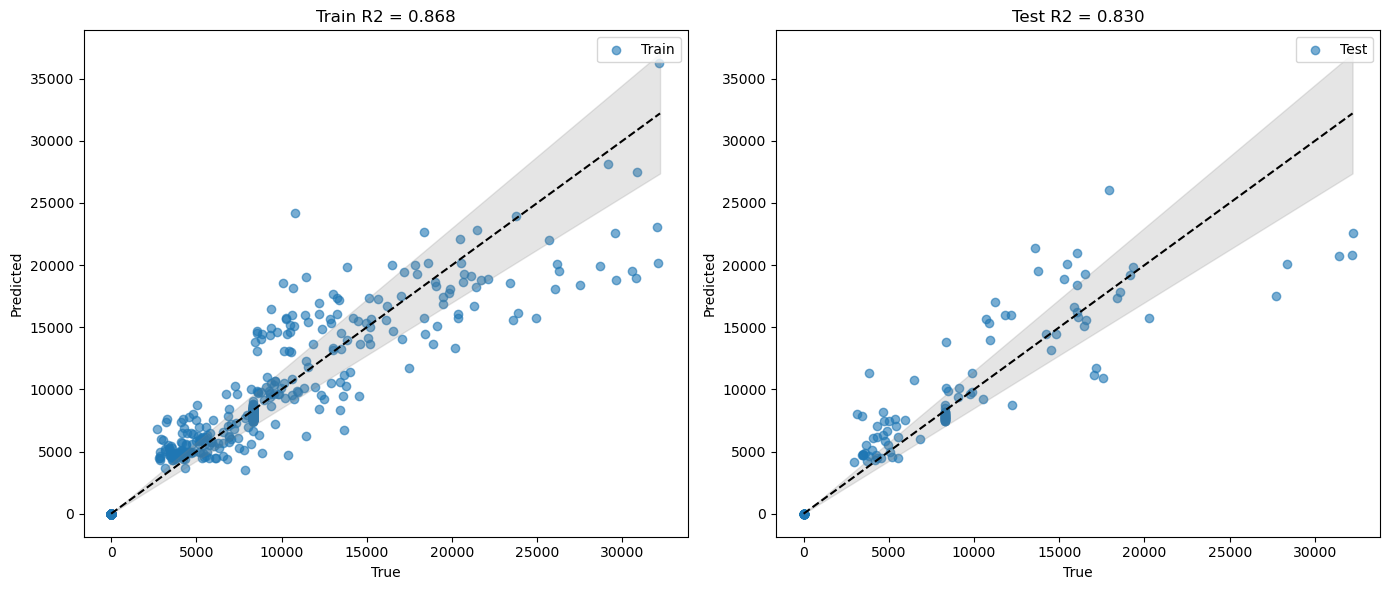

Training R2: 0.8680127326218123 Testing R2: 0.8301613249446407
Training MSE: 5591854.175006012 Testing MSE: 8464970.469767855
Training CV(RMSE): 0.3275983802806
Testing CV(RMSE): 0.3893736277295412


In [13]:
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import shap
import random
import os
import optuna

# === Reproducibility setup ===
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)
os.environ['TF_DETERMINISTIC_OPS'] = '1'

# === Load and preprocess data ===
data = pd.read_csv('prepared_data_1hr.csv', index_col=0)
timestep = 3600
data['time'] = (data['time'] // timestep) * timestep
data = data.groupby('time').last()

features = ['tesBed.uModActual.y', 'tesBed.TOut.y', 'tesBed.ave.y_his1', 'tesBed.weaBus.HGloHor']
target = ['Ptot']

X = data[features].values
Y = data[target].values
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

class PowerOutputMasked(tf.keras.layers.Layer):
    def call(self, inputs, power_pred):
        uMod = inputs[:, 0:1]
        mask = tf.cast(tf.not_equal(uMod, 0), tf.float32)
        return power_pred * mask

def build_model(input_shape, n_layers, n_units, activation, l2_lambda, dropout_rate):
    inputs = tf.keras.Input(shape=input_shape)
    x = tf.keras.layers.Normalization(axis=-1)(inputs)
    for _ in range(n_layers):
        x = tf.keras.layers.Dense(n_units, activation=activation,
                    kernel_regularizer=tf.keras.regularizers.L2(l2_lambda))(x)
        if dropout_rate > 0:
            x = tf.keras.layers.Dropout(dropout_rate)(x)
    raw_output = tf.keras.layers.Dense(1)(x)
    masked_output = PowerOutputMasked()(inputs, raw_output)
    return tf.keras.Model(inputs=inputs, outputs=masked_output)

def custom_pinn_loss_factory(x_input, model):
    def custom_pinn_loss(y_true, y_pred):
        mse = tf.reduce_mean(tf.square(y_true - y_pred))
        tes_mode = x_input[:, 0]
        penalty_ranges = {
            -1: (8000, 9000),
             1: (2000, 14000),
             2: (8000, 33000),
        }
        penalties = []
        for mode_val, (lower, upper) in penalty_ranges.items():
            mask = tf.equal(tes_mode, mode_val)
            out_of_bounds = tf.logical_or(y_pred < lower, y_pred > upper)
            penalty = tf.where(tf.logical_and(mask, out_of_bounds),
                               tf.square(tf.maximum(lower - y_pred, 0)) + tf.square(tf.maximum(y_pred - upper, 0)),
                               tf.zeros_like(y_pred))
            penalties.append(tf.reduce_mean(penalty))
        mode_bound_penalty = tf.add_n(penalties)

        with tf.GradientTape() as tape:
            tape.watch(x_input)
            y_pred_ = model(x_input)
        grads = tape.gradient(y_pred_, x_input)
        dP_dTout = grads[:, 1]
        mono_mask = tf.equal(tes_mode, 2)
        mono_penalty = tf.reduce_mean(tf.where(mono_mask, tf.maximum(0.0, -dP_dTout), tf.zeros_like(dP_dTout)))

        total_loss = mse + 0.1 * mode_bound_penalty + 0.05 * mono_penalty
        return total_loss
    return custom_pinn_loss

def objective(trial):
    n_layers = trial.suggest_int('n_layers', 2, 3)
    n_units = trial.suggest_categorical('n_units', [32, 64, 128])
    activation = trial.suggest_categorical('activation', ['relu', 'softplus', 'tanh'])
    batch_size = trial.suggest_categorical('batch_size', [32, 64])
    learning_rate = trial.suggest_loguniform('lr', 1e-4, 1e-1)
    l2_lambda = trial.suggest_loguniform('l2_lambda', 1e-6, 1e-2)
    dropout_rate = trial.suggest_uniform('dropout_rate', 0.0, 0.5)

    model = build_model((x_train.shape[1],), n_layers, n_units, activation, l2_lambda, dropout_rate)
    loss_fn = custom_pinn_loss_factory(tf.convert_to_tensor(x_train, dtype=tf.float32), model)
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate), loss=loss_fn)

    model.fit(x_train, y_train, epochs=300, batch_size=batch_size, validation_split=0.2, verbose=0)
    y_pred = model.predict(x_test).flatten()
    return -r2_score(y_test, y_pred)

study = optuna.create_study()
study.optimize(objective, n_trials=30)

best_params = study.best_params
final_model = build_model(
    (x_train.shape[1],),
    best_params['n_layers'],
    best_params['n_units'],
    best_params['activation'],
    best_params['l2_lambda'],
    best_params['dropout_rate']
)

loss_fn = custom_pinn_loss_factory(tf.convert_to_tensor(x_train, dtype=tf.float32), final_model)
final_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=best_params['lr']), loss=loss_fn)
final_model.fit(x_train, y_train, epochs=3000, batch_size=best_params['batch_size'], validation_split=0.2, verbose=1)
final_model.save('./results_pinn/pinn_power_model_best.h5')
print("Saved best model to ./results_pinn/pinn_power_model_best.h5")

# === Evaluation and Visualization of Best Model ===
y_pred_train = final_model.predict(x_train).flatten()
y_pred_test = final_model.predict(x_test).flatten()

r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)
mse_train = mean_squared_error(y_train, y_pred_train)
mse_test = mean_squared_error(y_test, y_pred_test)

plt.figure(figsize=(14, 6))
min_val = min(y_train.min(), y_test.min())
max_val = max(y_train.max(), y_test.max())
diagonal = np.linspace(min_val, max_val, 100)

plt.subplot(1, 2, 1)
plt.scatter(y_train, y_pred_train, label='Train', alpha=0.6)
plt.plot(diagonal, diagonal, 'k--')
plt.fill_between(diagonal, 0.85 * diagonal, 1.15 * diagonal, alpha=0.2, color='gray')
plt.title(f'Train R2 = {r2_train:.3f}')
plt.xlabel('True'); plt.ylabel('Predicted'); plt.legend()

plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred_test, label='Test', alpha=0.6)
plt.plot(diagonal, diagonal, 'k--')
plt.fill_between(diagonal, 0.85 * diagonal, 1.15 * diagonal, alpha=0.2, color='gray')
plt.title(f'Test R2 = {r2_test:.3f}')
plt.xlabel('True'); plt.ylabel('Predicted'); plt.legend()

plt.tight_layout()
plt.savefig('./results_pinn/power_scatter_best.png')
plt.show()

print("Training R2:", r2_train, "Testing R2:", r2_test)
print("Training MSE:", mse_train, "Testing MSE:", mse_test)
print("Training CV(RMSE):", mse_train**0.5 / np.mean(y_train))
print("Testing CV(RMSE):", mse_test**0.5 / np.mean(y_test))


1/1 [==============================] - 0s 66ms/step


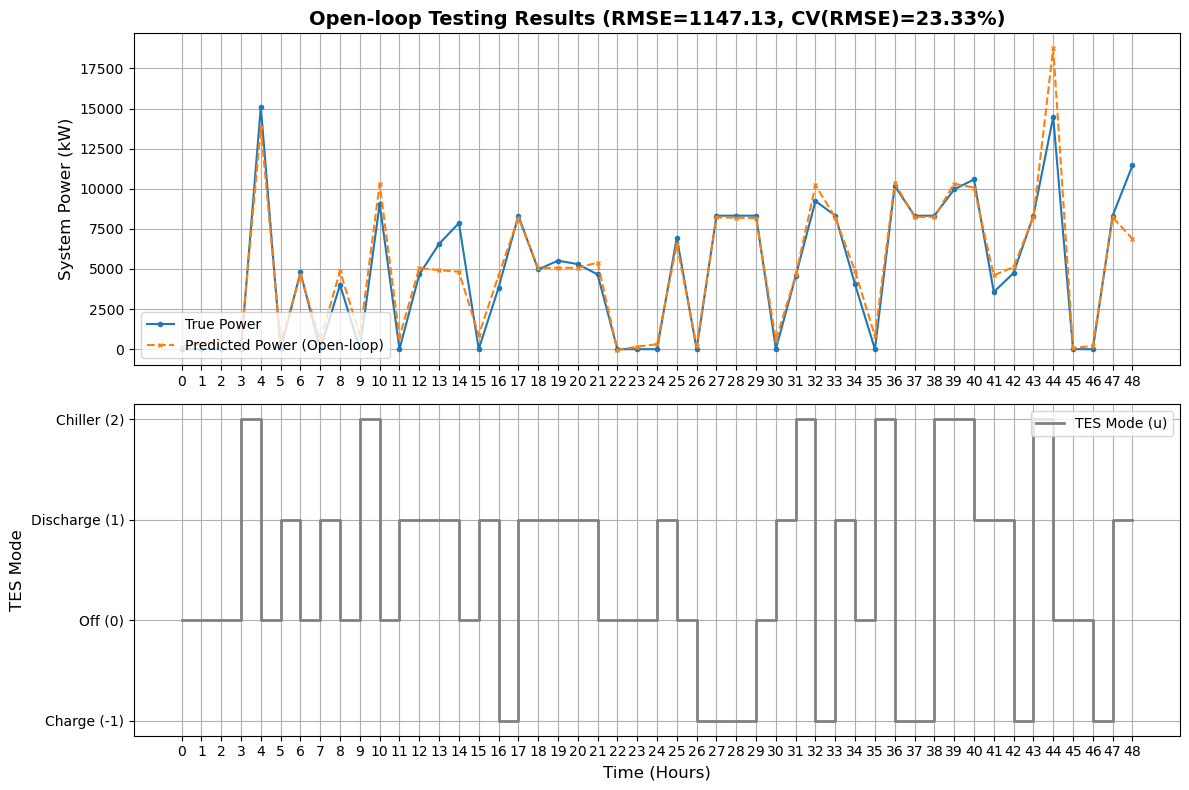

In [49]:
# === Open-loop Testing ===
#nn_model = tf.keras.models.load_model('./results_pinn/pinn_power_model.h5', compile=False)

# Use second half of dataset for testing
split_point = int(0.5 * len(X))
x_test = X[split_point:]
y_test = Y[split_point:]

start_step = 0
num_days = 2
steps_per_day = 24
total_steps = num_days * steps_per_day + 1

if start_step + total_steps > len(x_test):
    raise ValueError("Not enough data points for multi-day test.")

y_open_loop = []
y_true = []

# Open-loop test: recursively predict next step power
for step in range(total_steps):
    current_input = x_test[start_step + step:start_step + step + 1].copy()
    predicted_power = nn_model.predict(current_input)[0][0]
    y_open_loop.append(predicted_power)
    y_true.append(y_test[start_step + step][0])

y_open_loop = np.array(y_open_loop)
y_true = np.array(y_true)
rmse_open_loop = np.sqrt(np.mean((y_open_loop - y_true) ** 2))
cvrmse_open_loop = (rmse_open_loop / np.mean(y_true)) * 100

# TES mode = first input feature
u_sequence = x_test[start_step:start_step + total_steps, 0]

steps_per_hour = 1
hourly_indices = np.arange(0, total_steps, steps_per_hour)
hour_labels = np.arange(total_steps)

# === Open-loop Power Plot ===
plt.figure(figsize=(12, 8))

plt.subplot(2, 1, 1)
plt.plot(y_true, label='True Power', marker='o', markersize=3)
plt.plot(y_open_loop, label='Predicted Power (Open-loop)', linestyle='--', marker='x', markersize=3)
plt.xticks(hourly_indices, hour_labels)
plt.ylabel('System Power (kW)', fontsize=12)
plt.title(f'Open-loop Testing Results (RMSE={rmse_open_loop:.2f}, CV(RMSE)={cvrmse_open_loop:.2f}%)', fontsize=14, fontweight='bold')
plt.grid(True)
plt.legend(loc='lower left')

plt.subplot(2, 1, 2)
plt.step(range(total_steps), u_sequence, where='pre', color='gray', label='TES Mode (u)', linewidth=2)
plt.yticks([-1, 0, 1, 2], ['Charge (-1)', 'Off (0)', 'Discharge (1)', 'Chiller (2)'])
plt.ylabel('TES Mode', fontsize=12)
plt.xticks(hourly_indices, hour_labels)
plt.xlabel('Time (Hours)', fontsize=12)
plt.grid(True)
plt.legend(loc='upper right')

plt.tight_layout()
plt.savefig('./results_pinn/open_loop_test_power.png', dpi=300)
plt.show()


In [31]:
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import shap
import random
import os
from datetime import datetime

# Reproducibility setup
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)
os.environ['TF_DETERMINISTIC_OPS'] = '1'

# === Load and preprocess data ===
data = pd.read_csv('prepared_data_1hr.csv', index_col=0)
timestep = 3600
data['time'] = (data['time'] // timestep) * timestep
data = data.groupby('time').last()

features = ['tesBed.uModActual.y', 'tesBed.TOut.y', 'tesBed.ave.y']
target = ['Ptot']

X = data[features].values
Y = data[target].values

# Normalize target
y_scaler = StandardScaler()
Y = y_scaler.fit_transform(Y)
mean_p = y_scaler.mean_[0]
std_p = y_scaler.scale_[0]

def normalize_bounds(lower, upper):
    return (lower - mean_p) / std_p, (upper - mean_p) / std_p

# === Build model ===
def build_model(input_shape, x_train):
    normalizer = tf.keras.layers.Normalization(axis=-1)
    model = tf.keras.Sequential([
        normalizer,
        tf.keras.layers.Dense(64, activation='relu', kernel_regularizer=tf.keras.regularizers.L2(0.001)),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dense(1)
    ])
    normalizer.adapt(x_train)
    return model

# === Custom loss function ===
def custom_loss_factory(x_input, model, apply_monotonicity=False):
    tes_mode = x_input[:, 0]
    penalty_ranges = {
        -1: normalize_bounds(8000, 9000),
         1: normalize_bounds(2000, 14000),
         2: normalize_bounds(8000, 33000),
    }

    def custom_loss(y_true, y_pred):
        mse = tf.reduce_mean(tf.square(y_true - y_pred))
        penalty_mode_0 = tf.reduce_mean(
            tf.where(tf.equal(tes_mode, 0), tf.square(y_pred), tf.zeros_like(y_pred))
        )

        penalties = []
        for mode_val, (lower, upper) in penalty_ranges.items():
            mask = tf.equal(tes_mode, mode_val)
            out_of_bounds = tf.logical_or(y_pred < lower, y_pred > upper)
            penalty = tf.where(
                tf.logical_and(mask, out_of_bounds),
                tf.square(tf.maximum(lower - y_pred, 0)) + tf.square(tf.maximum(y_pred - upper, 0)),
                tf.zeros_like(y_pred)
            )
            penalties.append(tf.reduce_mean(penalty))
        mode_bound_penalty = tf.add_n(penalties)

        mono_penalty = 0.0
        if apply_monotonicity:
            with tf.GradientTape() as tape:
                tape.watch(x_input)
                y_pred_ = model(x_input)
            grads = tape.gradient(y_pred_, x_input)
            dP_dTout = grads[:, 1]
            mono_mask = tf.equal(tes_mode, 2)
            mono_penalty = tf.reduce_mean(
                tf.where(mono_mask, tf.maximum(0.0, -dP_dTout), tf.zeros_like(dP_dTout))
            )

        return mse + 0.01 * penalty_mode_0 + 0.01 * mode_bound_penalty + 0.01 * mono_penalty

    return custom_loss

# === K-Fold Cross Validation Training ===
apply_monotonicity = True
n_splits = 5
kf = KFold(n_splits=n_splits, shuffle=False)

fold_results = []
best_model = None
best_model_score = -np.inf
best_fold_data = None

os.makedirs('./results_pinn/shap_plots', exist_ok=True)
os.makedirs('./results_pinn/scatter_plots', exist_ok=True)

for fold, (train_index, test_index) in enumerate(kf.split(X)):
    print(f"\nTraining fold {fold+1}/{n_splits}...")
    x_train, x_test = X[train_index], X[test_index]
    y_train, y_test = Y[train_index], Y[test_index]

    model = build_model((x_train.shape[1],), x_train)
    loss_fn = custom_loss_factory(tf.convert_to_tensor(x_train, dtype=tf.float32), model, apply_monotonicity)
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4)
    model.compile(optimizer=optimizer, loss=loss_fn)

    log_dir = f"./results_pinn/logs_pinn/fold_{fold+1}_{datetime.now().strftime('%Y%m%d-%H%M%S')}"
    tensorboard_cb = tf.keras.callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1)
    early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
    lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=10)

    history = model.fit(
        x_train, y_train,
        epochs=1000,
        batch_size=64,
        validation_split=0.2,
        callbacks=[early_stopping, lr_scheduler, tensorboard_cb],
        verbose=0
    )

    # === Evaluation ===
    y_pred_train = y_scaler.inverse_transform(model.predict(x_train)).flatten()
    y_pred_test = y_scaler.inverse_transform(model.predict(x_test)).flatten()
    y_train_orig = y_scaler.inverse_transform(y_train)
    y_test_orig = y_scaler.inverse_transform(y_test)

    r2_train = r2_score(y_train_orig, y_pred_train)
    r2_test = r2_score(y_test_orig, y_pred_test)
    mse_train = mean_squared_error(y_train_orig, y_pred_train)
    mse_test = mean_squared_error(y_test_orig, y_pred_test)

    fold_results.append((r2_train, r2_test, mse_train, mse_test))

    print(f"Fold {fold+1} | R2 Test: {r2_test:.3f}, RMSE Test: {mse_test**0.5:.1f}, CV(RMSE): {mse_test**0.5/np.mean(y_test_orig):.3f}")

    if r2_test > best_model_score:
        best_model_score = r2_test
        best_model = model
        best_fold_data = (x_train, x_test, y_train, y_test, y_train_orig, y_test_orig, y_pred_train, y_pred_test)

    # === Save Scatter Plot ===
    min_val = min(y_train_orig.min(), y_test_orig.min())
    max_val = max(y_train_orig.max(), y_test_orig.max())
    diagonal = np.linspace(min_val, max_val, 100)

    plt.figure(figsize=(14, 6))
    plt.subplot(1, 2, 1)
    plt.scatter(y_train_orig, y_pred_train, label='Train', alpha=0.6)
    plt.plot(diagonal, diagonal, 'k--')
    plt.fill_between(diagonal, 0.85 * diagonal, 1.15 * diagonal, alpha=0.2, color='gray')
    plt.title(f'Train R2 = {r2_train:.3f}')
    plt.xlabel('True'); plt.ylabel('Predicted'); plt.legend()

    plt.subplot(1, 2, 2)
    plt.scatter(y_test_orig, y_pred_test, label='Test', alpha=0.6)
    plt.plot(diagonal, diagonal, 'k--')
    plt.fill_between(diagonal, 0.85 * diagonal, 1.15 * diagonal, alpha=0.2, color='gray')
    plt.title(f'Test R2 = {r2_test:.3f}')
    plt.xlabel('True'); plt.ylabel('Predicted'); plt.legend()

    plt.tight_layout()
    plt.savefig(f'./results_pinn/scatter_plots/fold_{fold+1}_power_scatter.png')
    plt.close()

# === Save the best model ===
best_model.save('./results_pinn/pinn_power_model.h5')

# === SHAP for best fold ===
x_train, x_test, y_train, y_test, y_train_orig, y_test_orig, y_pred_train, y_pred_test = best_fold_data
background = x_train[:100]
explainer = shap.DeepExplainer(best_model, background)
shap_values = explainer.shap_values(x_test[:100])
plt.figure()
shap.summary_plot(shap_values[0], features=x_test[:100], feature_names=features, show=False)
plt.title("SHAP Summary Plot - Best Model")
plt.savefig('./results_pinn/shap_plots/shap_summary_best_power_model.png')
plt.close()

# === Final Summary of K-Fold Results (with RMSE and CV(RMSE)) ===
print("\n=== K-Fold Summary ===")
for i, (r2_tr, r2_te, mse_tr, mse_te) in enumerate(fold_results):
    rmse_te = mse_te ** 0.5
    cv_rmse_te = rmse_te / np.mean(y_test_orig)
    print(f"Fold {i+1}: Train R2={r2_tr:.3f}, Test R2={r2_te:.3f}, Test RMSE={rmse_te:.1f}, Test CV(RMSE)={cv_rmse_te:.3f}")

avg_r2_test = np.mean([r[1] for r in fold_results])
avg_rmse_test = np.mean([np.sqrt(r[3]) for r in fold_results])
avg_cv_rmse_test = np.mean([np.sqrt(r[3]) / np.mean(y_test_orig) for r in fold_results])
print(f"\nAverage Test R2: {avg_r2_test:.3f}, Average Test RMSE: {avg_rmse_test:.1f}, Average CV(RMSE): {avg_cv_rmse_test:.3f}")



Training fold 1/5...
5/5 [==============================] - 0s 2ms/step
Fold 1 | R2 Test: 0.822, RMSE Test: 3164.1, CV(RMSE): 0.413

Training fold 2/5...
5/5 [==============================] - 0s 2ms/step
Fold 2 | R2 Test: 0.878, RMSE Test: 1800.6, CV(RMSE): 0.254

Training fold 3/5...
5/5 [==============================] - 0s 1ms/step
Fold 3 | R2 Test: 0.910, RMSE Test: 1689.4, CV(RMSE): 0.269

Training fold 4/5...
5/5 [==============================] - 0s 1ms/step
Fold 4 | R2 Test: 0.890, RMSE Test: 2311.4, CV(RMSE): 0.304

Training fold 5/5...
5/5 [==============================] - 0s 1ms/step
Fold 5 | R2 Test: 0.815, RMSE Test: 3189.1, CV(RMSE): 0.414
array([[ 1.     , 17.7925 , 22.7524 ],
       [ 0.     , 18.26434, 23.59084],
       [-1.     , 19.9317 , 23.79595],
       [-1.     , 22.14208, 24.02374],
       [-1.     , 23.84335, 25.03182],
       [-1.     , 25.54333, 25.58138],
       [ 1.     , 26.67416, 24.18347],
       [ 2.     , 27.1914 , 24.14382],
       [ 0.     , 27.19

Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.
`tf.keras.backend.set_learning_phase` is deprecated and will be removed after 2020-10-11. To update it, simply pass a True/False value to the `training` argument of the `__call__` method of your layer or model.


array([[ 1.     , 28.2871 , 25.16888],
       [ 0.     , 27.21127, 28.62878],
       [ 0.     , 27.1937 , 28.93884],
       [ 2.     , 27.80343, 25.5067 ],
       [ 0.     , 26.14758, 29.05212],
       [ 0.     , 25.6424 , 28.76168],
       [ 1.     , 19.42022, 24.8875 ],
       [ 1.     , 19.9954 , 24.02917],
       [ 0.     , 19.988  , 27.27072],
       [-1.     , 21.09683, 27.33782],
       [ 2.     , 21.1    , 24.62576],
       [ 1.     , 21.1    , 24.29547],
       [ 1.     , 21.1    , 24.05447],
       [-1.     , 21.1    , 26.47363],
       [ 1.     , 21.1    , 24.33962],
       [ 2.     , 20.02776, 24.19256],
       [-1.     , 19.41555, 26.1895 ],
       [ 2.     , 19.38568, 24.33413],
       [-1.     , 21.07412, 26.0761 ],
       [ 2.     , 21.08358, 24.2572 ],
       [-1.     , 22.1451 , 27.0349 ],
       [-1.     , 24.9561 , 27.5515 ],
       [ 2.     , 25.59115, 24.78546],
       [ 1.     , 25.61898, 24.4155 ],
       [ 0.     , 23.9446 , 27.6743 ],
       [ 2.     , 23.3436

#### Run TensorBoard to track loss and optimizer behavior

In [ ]:
%load_ext tensorboard
%tensorboard --logdir=./results_pinn/logs_pinn

## Post-analysis of model performance

1/1 [==============================] - 0s 43ms/step


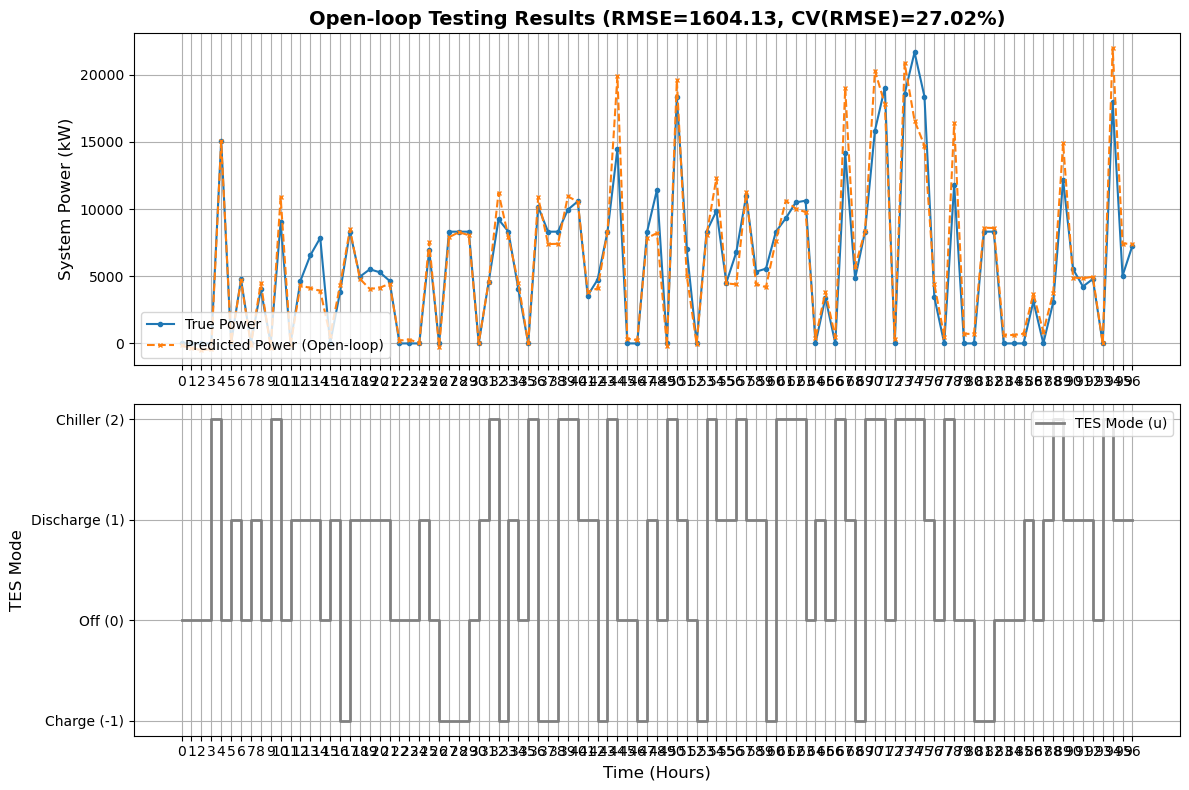

In [40]:
# === Open-loop Testing ===
# Dummy loss function to bypass loading
def dummy_loss(y_true, y_pred):
    return tf.reduce_mean(tf.square(y_true - y_pred))

nn_model = tf.keras.models.load_model(
    './results_pinn/pinn_power_model.h5',
    custom_objects={'custom_loss': dummy_loss}
)


# Use second half of dataset for testing
split_point = int(0.5 * len(X))
x_test = X[split_point:]
y_test = y_scaler.inverse_transform(Y[split_point:])  # unnormalize for metrics

start_step = 0
num_days = 2
steps_per_day = 24
total_steps = num_days * steps_per_day + 1

if start_step + total_steps > len(x_test):
    raise ValueError("Not enough data points for multi-day test.")

y_open_loop = []
y_true = []

# Open-loop test: recursively predict next step power
for step in range(total_steps):
    current_input = x_test[start_step + step:start_step + step + 1].copy()
    predicted_power = y_scaler.inverse_transform(nn_model.predict(current_input))[0][0]
    y_open_loop.append(predicted_power)
    y_true.append(y_test[start_step + step][0])

y_open_loop = np.array(y_open_loop)
y_true = np.array(y_true)
rmse_open_loop = np.sqrt(np.mean((y_open_loop - y_true) ** 2))
cvrmse_open_loop = (rmse_open_loop / np.mean(y_true)) * 100

# TES mode = first input feature
u_sequence = x_test[start_step:start_step + total_steps, 0]

steps_per_hour = 1
hourly_indices = np.arange(0, total_steps, steps_per_hour)
hour_labels = np.arange(total_steps)

# === Open-loop Power Plot ===
plt.figure(figsize=(12, 8))

plt.subplot(2, 1, 1)
plt.plot(y_true, label='True Power', marker='o', markersize=3)
plt.plot(y_open_loop, label='Predicted Power (Open-loop)', linestyle='--', marker='x', markersize=3)
plt.xticks(hourly_indices, hour_labels)
plt.ylabel('System Power (kW)', fontsize=12)
plt.title(f'Open-loop Testing Results (RMSE={rmse_open_loop:.2f}, CV(RMSE)={cvrmse_open_loop:.2f}%)', fontsize=14, fontweight='bold')
plt.grid(True)
plt.legend(loc='lower left')

plt.subplot(2, 1, 2)
plt.step(range(total_steps), u_sequence, where='pre', color='gray', label='TES Mode (u)', linewidth=2)
plt.yticks([-1, 0, 1, 2], ['Charge (-1)', 'Off (0)', 'Discharge (1)', 'Chiller (2)'])
plt.ylabel('TES Mode', fontsize=12)
plt.xticks(hourly_indices, hour_labels)
plt.xlabel('Time (Hours)', fontsize=12)
plt.grid(True)
plt.legend(loc='upper right')

plt.tight_layout()
plt.savefig('./results_pinn/open_loop_test_power.png', dpi=300)
plt.show()


## Model Sanity Check

In [10]:
# Sensitivity analysis using SHAP

2/2 [==============================] - 0s 5ms/step


  0%|          | 0/100 [00:00<?, ?it/s]

10/10 [==============================] - 0s 3ms/step


  1%|          | 1/100 [00:00<00:26,  3.75it/s]

10/10 [==============================] - 0s 2ms/step


...

 98%|█████████▊| 98/100 [00:23<00:00,  4.77it/s]

10/10 [==============================] - 0s 1ms/step


 99%|█████████▉| 99/100 [00:23<00:00,  4.81it/s]

10/10 [==============================] - 0s 2ms/step


100%|██████████| 100/100 [00:23<00:00,  4.25it/s]


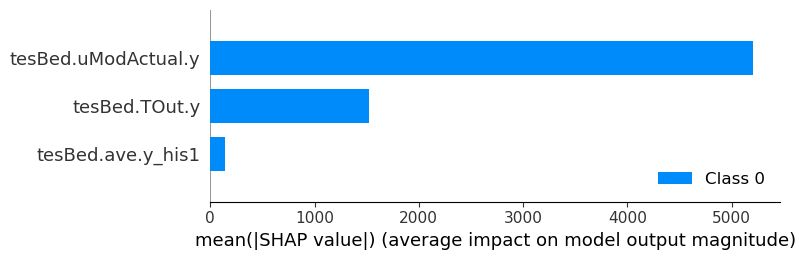

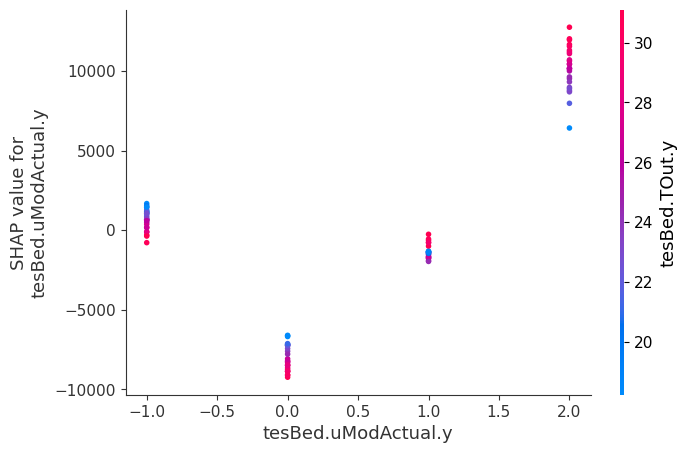

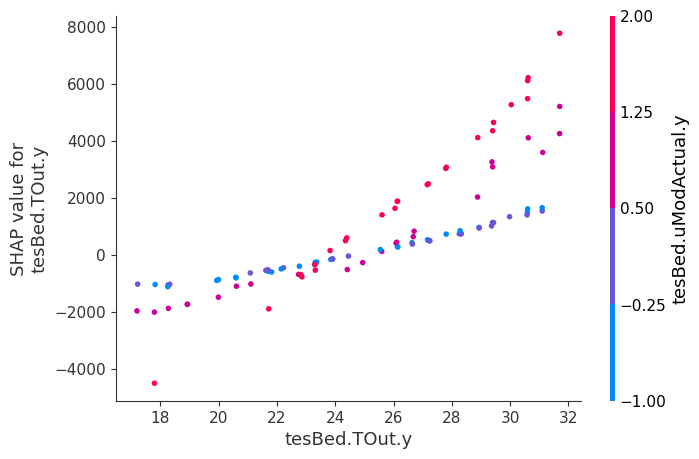

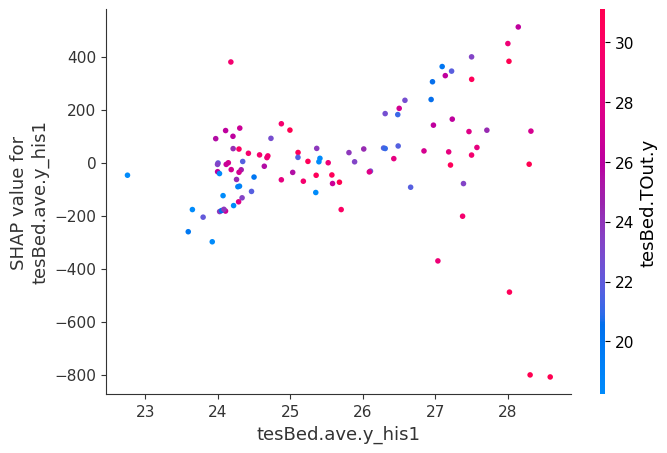

In [8]:
import shap
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# === Define custom layer ===
class PowerOutputMasked(tf.keras.layers.Layer):
    def __init__(self, **kwargs):
        super(PowerOutputMasked, self).__init__(**kwargs)

    def call(self, inputs, raw_output=None, **kwargs):
        # If raw_output was passed as a keyword, fall back to it
        if raw_output is None:
            raw_output = kwargs.get('power_pred', None)
        if raw_output is None:
            raise ValueError("Missing raw_output or 'power_pred' input for PowerOutputMasked.")

        return tf.where(inputs[:, 0:1] == 0.0, 0.0, raw_output)

# === Load data ===
data = pd.read_csv('prepared_data_1hr.csv', index_col=0)
features = ['tesBed.uModActual.y', 'tesBed.TOut.y', 'tesBed.ave.y_his1']
target = ['Ptot']
X = data[features].values
Y = data[target].values

# === Load model with custom layer ===
model = tf.keras.models.load_model(
    './results_pinn/pinn_power_model.h5',
    custom_objects={'PowerOutputMasked': PowerOutputMasked},
    compile=False
)

# === SHAP Explanation ===
explainer = shap.KernelExplainer(model.predict, X[:50])
shap_values = explainer.shap_values(X[:100])

# === SHAP Summary Plot ===
shap.summary_plot(shap_values, X[:100], feature_names=features)

# === SHAP Dependence Plots ===
for i, feature in enumerate(features):
    shap.dependence_plot(i, shap_values[0], X[:100], feature_names=features)
